In [2]:
import pandas as pd 

In [5]:
# names = [
#     "entropy0.01", "entropy0.0"
# ]
# dfs = [
#     pd.read_json(path_or_buf="~/out/fixed/Qwen/Qwen2.5-7B_entropy_0.01_kl_0.001_20250808_130223/metrics.jsonl", lines=True),
#     pd.read_json(path_or_buf="~/out/fixed/Qwen/Qwen2.5-7B_entropy_0.0_kl_0.001_20250808_130226/metrics.jsonl", lines=True)
# ]

names = [
    "mask_pos", "mask_neg", "regular", "balanced", "linear", "rnd"
]

In [ ]:

dfs = [
    pd.read_json(path_or_buf="~/out/entropy_logging2/Qwen/Qwen2.5-1.5B_mask_pos_entropy_0.0_kl_0.0_20250925_200726/metrics.jsonl", lines=True),
    pd.read_json(path_or_buf="~/out/entropy_logging2/Qwen/Qwen2.5-1.5B_mask_neg_entropy_0.0_kl_0.0_20250925_200734/metrics.jsonl", lines=True),
    pd.read_json(path_or_buf="~/out/entropy_logging2/Qwen/Qwen2.5-1.5B_regular_entropy_0.0_kl_0.0_20250925_200742/metrics.jsonl", lines=True),
    pd.read_json(path_or_buf="~/out/entropy_logging2/Qwen/Qwen2.5-1.5B_balanced_entropy_0.0_kl_0.0_20250925_200949/metrics.jsonl", lines=True),
    pd.read_json(path_or_buf="~/out/entropy_logging2/Qwen/Qwen2.5-1.5B_linear_entropy_0.0_kl_0.0_20250925_201005/metrics.jsonl", lines=True),
    pd.read_json(path_or_buf="~/out/entropy_logging2/Qwen/Qwen2.5-1.5B_rnd_entropy_0.0_kl_0.0_20250925_200703/metrics.jsonl", lines=True)
]

/tmp/ipykernel_46607/3992562168.py:2: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  pd.read_json(path_or_buf="~/out/entropy_logging/Qwen/Qwen2.5-1.5B_balanced_entropy_0.0_kl_0.0_20250925_200949/metrics.jsonl", lines=True),


ValueError: Expected object or value

In [3]:
dfs[0].columns

Index(['step', 'critic/kl', 'critic/kl_coeff', 'global_seqlen/min',
       'global_seqlen/max', 'global_seqlen/minmax_diff',
       'global_seqlen/balanced_min', 'global_seqlen/balanced_max',
       'global_seqlen/mean', 'total_seen_samples', 'actor/entropy',
       'actor/pg_loss', 'actor/pg_clipfrac', 'actor/ppo_kl', 'actor/grad_norm',
       'perf/estimated_flops_per_update', 'perf/mfu/actor',
       'perf/max_memory_allocated_gb', 'perf/max_memory_reserved_gb',
       'perf/cpu_memory_used_gb', 'actor/lr', 'critic/score/mean',
       'critic/score/max', 'critic/score/min', 'critic/rewards/mean',
       'critic/rewards/max', 'critic/rewards/min', 'critic/advantages/mean',
       'critic/advantages/max', 'critic/advantages/min', 'critic/returns/mean',
       'critic/returns/max', 'critic/returns/min', 'response_length/mean',
       'response_length/max', 'response_length/min',
       'response_length/clip_ratio', 'prompt_length/mean', 'prompt_length/max',
       'prompt_length/min', 

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_(name : str, window_size=10):
    window = np.ones(shape=(window_size,))
    for label, df in zip(names, dfs):
        ys = df[name].to_numpy()
        ys = np.convolve(ys, window)
        ys = ys[~np.isnan(ys)]

        plt.plot(ys, label=label)
        plt.title(f"Metric: {name}, sliding-window size: {window_size}")
    plt.legend()


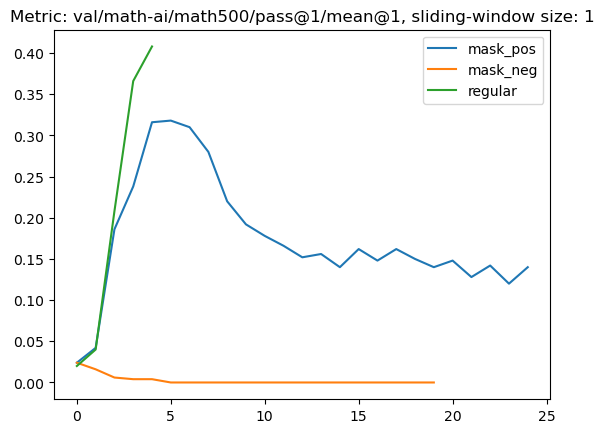

In [5]:
plot_('val/math-ai/math500/pass@1/mean@1', window_size=1)

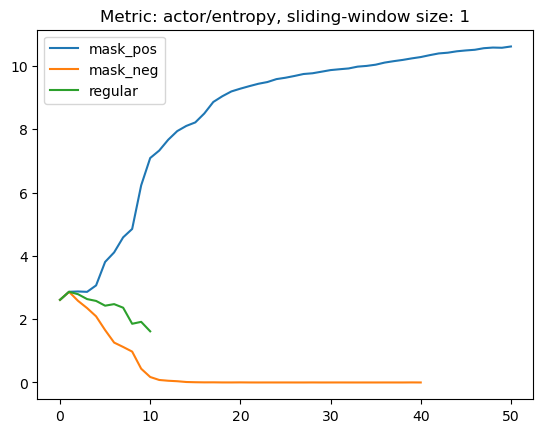

In [6]:
plot_('actor/entropy', window_size=1)

In [11]:
import os

In [15]:
names = [
    "mask_pos", "mask_neg", "regular"
]
dirs = [
    "/u/rfechner/out/entropy_logging/Qwen/Qwen2.5-1.5B_mask_pos_entropy_0.0_kl_0.0_20250917_104220/entropy_dumps",
    "/u/rfechner/out/entropy_logging/Qwen/Qwen2.5-1.5B_mask_neg_entropy_0.0_kl_0.0_20250917_104207/entropy_dumps",
    "/u/rfechner/out/entropy_logging/Qwen/Qwen2.5-1.5B_regular_entropy_0.0_kl_0.0_20250917_104236/entropy_dumps"
]
for d in dirs:
    assert os.path.isdir(d)

In [24]:
import pickle
import pathlib

def load_entropy_dumps(path : str) -> list[dict]:
    files, indeces = [], []
    for file in os.listdir(path):
        p = pathlib.Path(file)
        index = int(p.name.split('-')[1].replace('.pickle', ''))
        indeces.append(index)

        with open(os.path.join(path, file), 'rb') as tmp:
            d = pickle.load(tmp)
        files.append(d)

    out = [v for v, s in sorted(zip(files, indeces), key=lambda x: x[1])]
    return out


In [25]:
logs = [
    load_entropy_dumps(path) for path in dirs
]

In [ ]:
logs[0][0]

{'deltas': array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 8.5106383e-10, -4.0809240e-08,  6.9327747e-13, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        ...,
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],
       shape=(512, 768), dtype=float32),
 'advantages': array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        

#### Analysis

- would like to see the predicted delta in entropy (mean) versus the real entropy.
- normalize the change in entropy by the length of the array, then sum over first axis to get the mean entropy change over position.
    -> sum over all epochs to get the mean change of entropy per position over all steps.


In [45]:
from typing import *
def calc_averages(log) -> Tuple[float, float]:
    pass

def cumulative_entropy_preds(log, axis=(1, 2)) -> np.ndarray:
    deltas = np.stack([l['deltas'] for l in log]) # (steps, batchsize, 768)
    out = deltas.mean(axis=axis)
    out = np.cumsum(out)
    return out

def entropy_preds(log, axis=(1, 2)) -> np.ndarray:
    deltas = np.stack([l['deltas'] for l in log]) # (steps, batchsize, 768)
    out = deltas.mean(axis=axis)
    return out

In [39]:
pred_entropy = {
    name : cumulative_entropy_preds(log) for name, log in zip(names, logs)
}

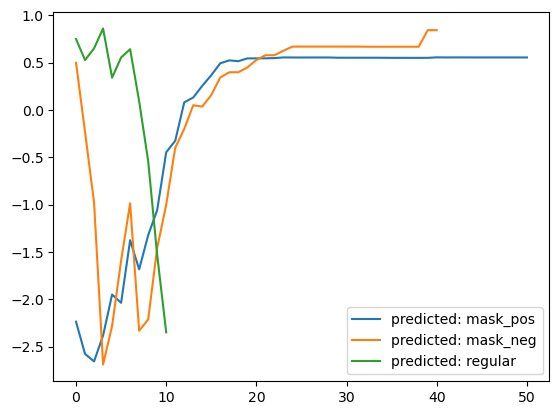

In [41]:
for name, entry in pred_entropy.items():
    normalized = (entry - entry.mean()) / entry.std()
    plt.plot(range(len(normalized)), normalized, label=f"predicted: {name}")

plt.legend()
plt.show()

observation: this plot correlates with the true entropy for the regular and mask_pos run. However for the mask_neg run it doesn't...

In [49]:
position_entropy_change = {
    name : entropy_preds(log, axis=(0, 1)) for name, log in zip(names, logs)
}

In [53]:
import numpy as np

def gaussian_kernel_1d(k: int, sigma: float = None) -> np.ndarray:
    """
    Generate a 1D Gaussian filter kernel of length k.
    
    Args:
        k (int): The size of the kernel (must be odd for symmetry).
        sigma (float, optional): Standard deviation of the Gaussian. 
                                 If None, it is set to k/6 (covers ~99% of distribution).
    
    Returns:
        np.ndarray: A 1D Gaussian kernel normalized to sum to 1.
    """
    if k % 2 == 0:
        raise ValueError("Kernel size k must be odd for symmetry.")
    
    if sigma is None:
        sigma = k / 6  # heuristic: so that ±3σ fits into kernel
    
    x = np.arange(-(k // 2), k // 2 + 1)
    kernel = np.exp(-0.5 * (x / sigma) ** 2)
    kernel /= kernel.sum()
    
    return kernel

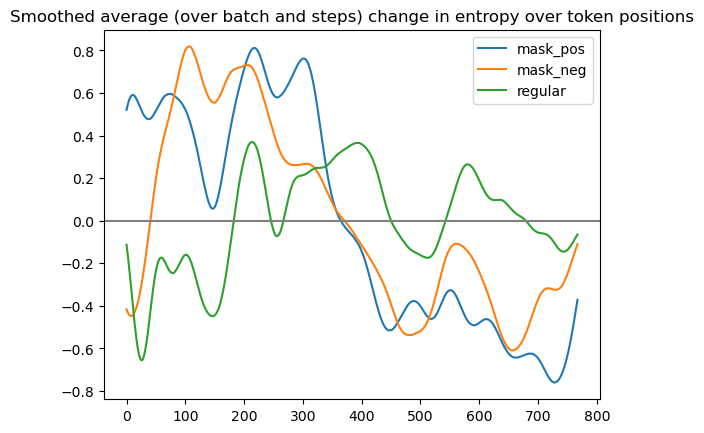

In [59]:
kernel_size=101
kernel = gaussian_kernel_1d(k=kernel_size)

for name, entry in position_entropy_change.items():
    normalized = (entry - entry.mean()) / entry.std()
    smoothed = np.convolve(normalized, v=kernel, mode='same')
    plt.plot(range(len(smoothed)), smoothed, label=f"{name}")


plt.axhline(0, xmin=0, xmax=767, color='gray')
plt.title('Smoothed average (over batch and steps) change in entropy over token positions')
plt.legend()
plt.show()

observation: gotta note that any interpretation of mask_neg is hard, as the policy seems to have degenerated quite quickly. Mask_pos seems to have increased the entropy in the initial response,
while degrading the entropy in the latter sections of the response.

In [61]:
batch_axis = (1,)
position_entropy_change = {
    name : entropy_preds(log, axis=batch_axis) for name, log in zip(names, logs)
}

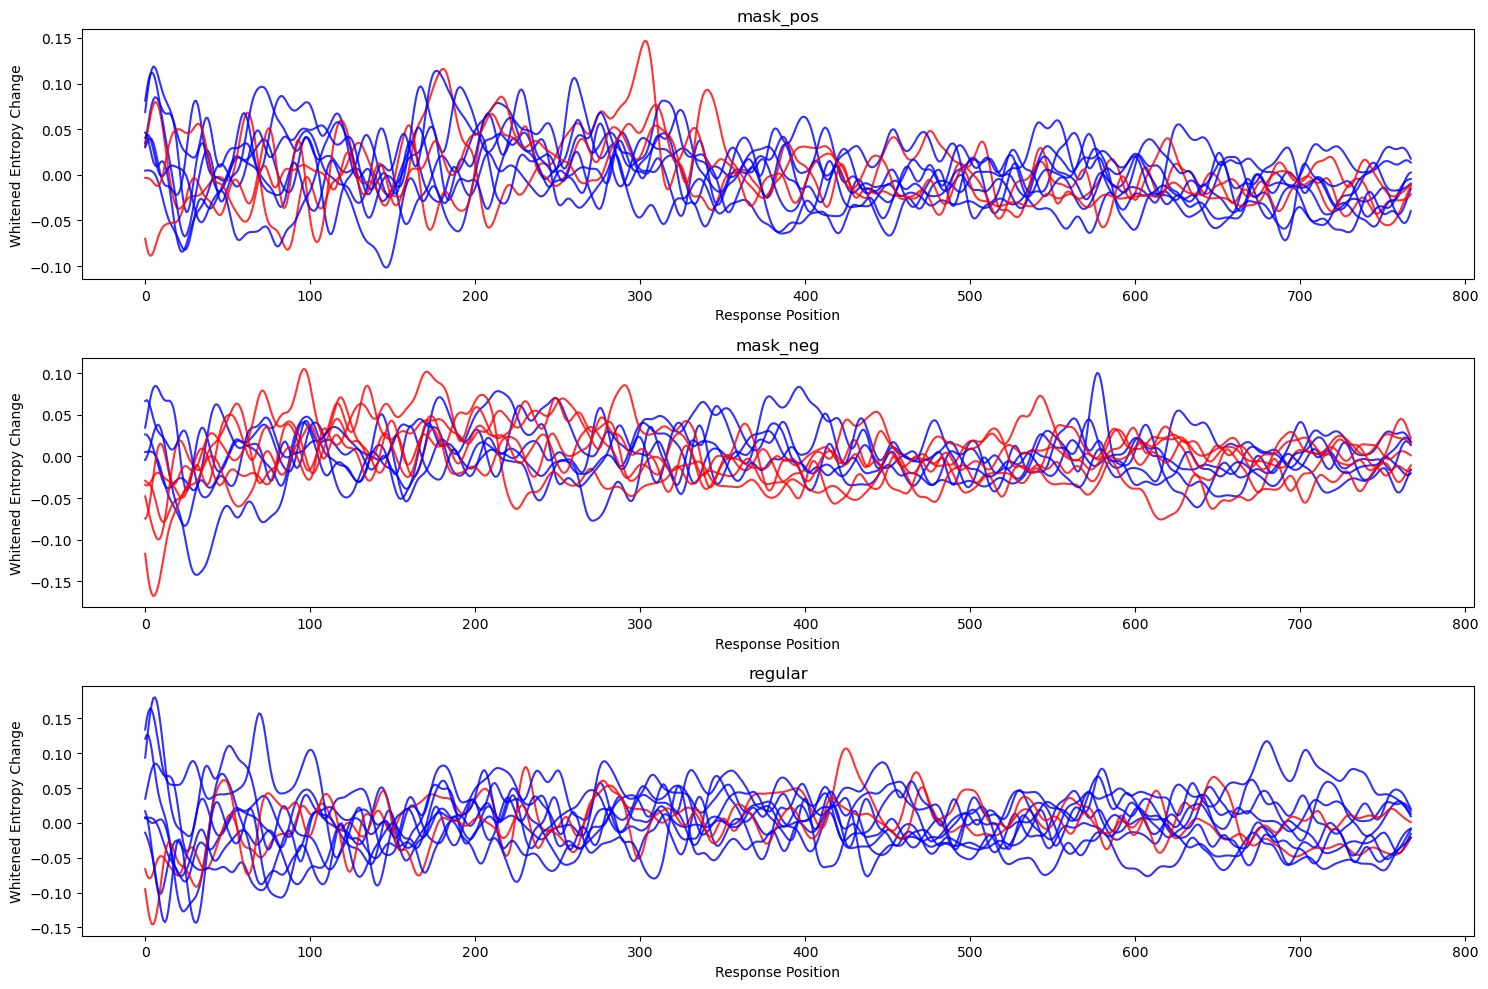

In [65]:

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(15, 10))
kernel = gaussian_kernel_1d(k=25)

for ax, (name, entry) in zip(axs, position_entropy_change.items()):
    entry = entry[:10, ...]  # clamp to first 10 steps
    steps, response_length = entry.shape

    # z-score each row: preserve sign
    mean = entry.mean(axis=1, keepdims=True)
    std = entry.std(axis=1, keepdims=True)
    normed = (entry - mean) / (std + 1e-8)

    for i in range(steps):
        smoothed = np.convolve(normed[i], kernel, mode="same")
        total_change = smoothed.sum()

        # pick color based on sign of sum
        color = "blue" if total_change < 0 else "red"

        ax.plot(smoothed, color=color, alpha=0.8)

    ax.set_title(name)
    ax.set_xlabel("Response Position")
    ax.set_ylabel("Whitened Entropy Change")

plt.tight_layout()
plt.show()


observation: Seems like the change in the entropy of the first responses came mostly from the first few steps for mask_pos, whilst the regular run is still